# **Machine Learning**

## Import dataset

In [54]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
from src.models.preprocessing import preprocessing

In [55]:
# Loading the data
input_path = Path("..") / 'data' / 'processed' / 'dataset_processed.csv'
df = pd.read_csv(input_path)
df = df.set_index("date_index", drop=False)
df.index = pd.to_datetime(df.index)
display(df.columns)

Index(['latitude', 'longitude', 'temperature_2m_max', 'sunrise', 'sunset',
       'daylight_duration', 'precipitation_sum', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'cloud_cover_mean', 'pressure_msl_mean',
       'wind_speed_10m_mean', 'soil_moisture_0_to_100cm_mean',
       'soil_temperature_0_to_100cm_mean', 'code_bss', 'date_index', 'bss_id',
       'niveau_nappe_eau', 'mode_obtention', 'nom_producteur', 'P_cum_30d',
       'P_cum_90d', 'Peff_cum_30d', 'Peff_cum_90d', 'Temperature_mean_30d',
       'Temperature_mean_90d', 'SPLI', 'SPI', 'SETI', 'SSTI', 'SSRI', 'SWSI',
       'SCCI', 'SPMI', 'SPEI', 'SSMI'],
      dtype='str')

In [56]:
df.columns.tolist()

['latitude',
 'longitude',
 'temperature_2m_max',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'date_index',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur',
 'P_cum_30d',
 'P_cum_90d',
 'Peff_cum_30d',
 'Peff_cum_90d',
 'Temperature_mean_30d',
 'Temperature_mean_90d',
 'SPLI',
 'SPI',
 'SETI',
 'SSTI',
 'SSRI',
 'SWSI',
 'SCCI',
 'SPMI',
 'SPEI',
 'SSMI']

## XGBoost Regressor

In [57]:
# Import libraries
#from src.models.preprocessing import preprocessing
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [58]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    XGBoost Regressor predicting groundwater level (niveau_nappe_eau).
    Returns predictions and evaluation metrics (R2_train, R2_test, RMSE, MAE).
    """
    X_train, X_test, y_train, y_test = preprocessing(df, test_size=30)

    # --- Model ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Predictions ---
    predictions_xgboost_reg = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Metrics ---
    evaluation_metrics_xgboost_reg = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [model.score(X_test, y_test)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)],
        "MAPE"     : [np.mean(np.abs((y_test - y_pred) / y_test)) * 100],
        "Biais"    : [np.mean(y_pred - y_test.values)]
    }, index=["niveau_nappe_eau"])

    return predictions_xgboost_reg, evaluation_metrics_xgboost_reg

In [59]:
predictions_xgboost_reg, evaluation_metrics_xgboost_reg = xgboost_regressor(df)

In [60]:
predictions_xgboost_reg

,y_test,y_pred
date_index,,
2026-06-20,104.15,103.481224
2026-06-21,104.16,103.329178
2026-06-22,104.13,103.484123
2026-06-23,104.14,103.484123
2026-06-24,104.15,103.647995
2026-06-25,104.15,103.629524
2026-06-26,104.15,103.606506
2026-06-27,104.12,103.721100
2026-06-28,104.13,103.679138


In [61]:
evaluation_metrics_xgboost_reg

,R2_train,R2_test,RMSE,MAE,MAPE,Biais
niveau_nappe_eau,0.842575,-22.1237,0.550849,0.536315,0.515504,-0.536315


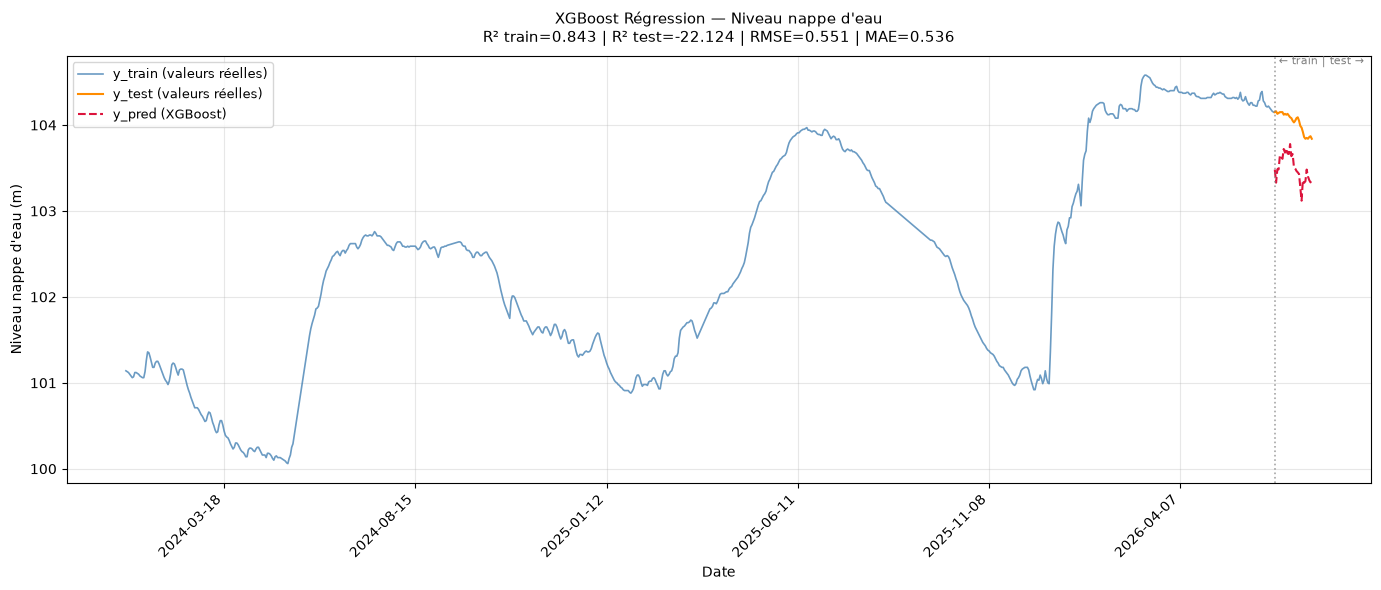

In [66]:
plot_start = "2024-01-01"  # ← modifie cette date si besoin, ou None pour tout afficher

# --- Filtrage optionnel de la date de début ---
y_train_plot = y_train[y_train.index >= pd.Timestamp(plot_start)] if plot_start else y_train

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_train_plot.index, y_train_plot.values,
        color="steelblue", linewidth=1.2, alpha=0.8,
        label="y_train (valeurs réelles)")

ax.plot(predictions_xgboost_reg.index, predictions_xgboost_reg["y_test"],
        color="darkorange", linewidth=1.5,
        label="y_test (valeurs réelles)")

ax.plot(predictions_xgboost_reg.index, predictions_xgboost_reg["y_pred"],
        color="crimson", linewidth=1.5, linestyle="--",
        label="y_pred (XGBoost)")

# --- Séparateur train / test ---
split_date = predictions_xgboost_reg.index[0]
ax.axvline(split_date, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(split_date, ax.get_ylim()[1],
        " ← train | test →", fontsize=8, color="gray", va="top")

# --- Titre avec métriques ---
row = evaluation_metrics_xgboost_reg.iloc[0]
ax.set_title(
    f"XGBoost Régression — Niveau nappe d'eau\n"
    f"R² train={row['R2_train']:.3f} | R² test={row['R2_test']:.3f} | "
    f"RMSE={row['RMSE']:.3f} | MAE={row['MAE']:.3f}",
    fontsize=11, pad=10
)

# --- Axes sans mdates ---
ax.set_xlabel("Date")
ax.set_ylabel("Niveau nappe d'eau (m)")
ax.xaxis.set_major_locator(plt.MaxNLocator(10))  # ← max 10 ticks sur l'axe x
fig.autofmt_xdate(rotation=45)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Variance = moyenne des écarts au carré


**Interprétatoin**

Le R² est une métrique qui mesure la proportion de variance expliquée par le modèle. Quand la série cible est quasi-stationnaire — comme un niveau de nappe qui ne varie que de quelques centimètres sur 30 jours — sa variance totale est extrêmement faible. Or le R² divise l'erreur du modèle par cette variance : si le dénominateur est minuscule, le moindre décalage systématique suffit à faire exploser le ratio à la baisse, même si l'erreur absolue reste négligeable en regard de la valeur cible.

Dans notre cas, le modèle se trompe en moyenne de 0.54 m sur une nappe autour de 104 m, soit une erreur relative de 0.5% — ce que confirment le RMSE, le MAE et le MAPE. Pourtant le R² atteint -22, car la série de test est si plate que cette erreur de 54 cm représente plusieurs fois sa variance totale.

En d'autres termes, un R² négatif et extrême n'indique pas nécessairement un modèle inutile — il indique surtout que la métrique est inadaptée au problème. Sur une série temporelle à faible variabilité, le R² perd son pouvoir discriminant et seuls le RMSE, le MAE et le MAPE permettent d'évaluer correctement la qualité des prédictions.

# **Test avec rolling de 30 jours**

Train : 2017-01-01 → 2023-12-31 (2556 jours)
Test  : 2024-01-01 → 2024-01-31 (31 jours)

y_train mean=102.909  std=1.018
y_test  mean=101.156  std=0.087  var=0.0076

                  R2_train   R2_test     RMSE       MAE      MAPE     Biais  Variance
niveau_nappe_eau  0.875322 -23.32245  0.42231  0.399908  0.395395  0.399908  0.007577


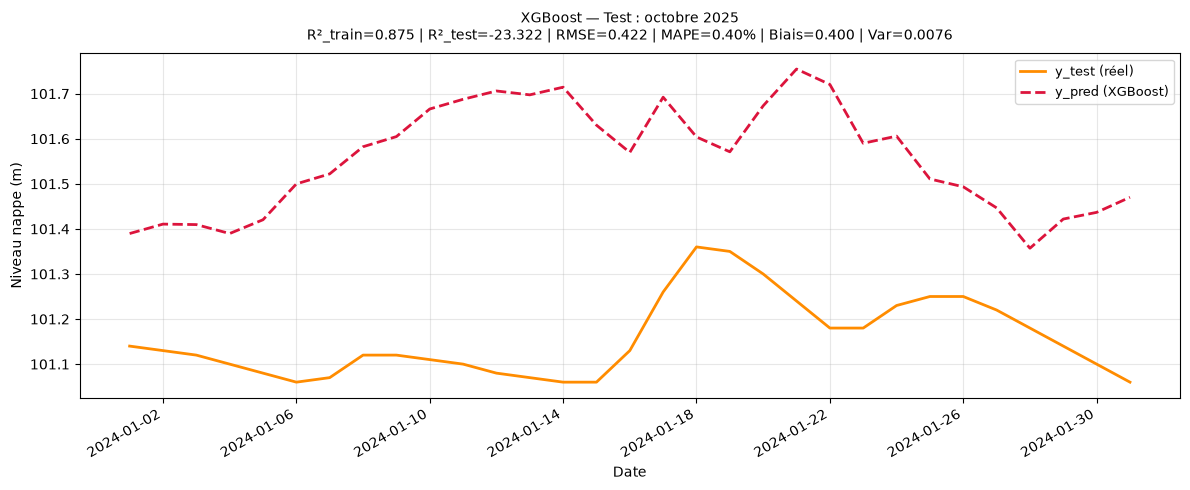

In [71]:
def xgboost_octobre_2025(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    XGBoost Regressor — test set fixé sur octobre 2025.
    """
    # --- Preprocessing ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau"
    df = df[feature_cols + [target_col]].dropna()

    # --- Split : train = tout avant oct 2025, test = oct 2025 ---
    test_mask = (df.index.year == 2024) & (df.index.month == 1)
    df_train  = df[df.index < "2024-01-01"]
    df_test   = df[test_mask]

    X_train = df_train[feature_cols]
    y_train = df_train[target_col]
    X_test  = df_test[feature_cols]
    y_test  = df_test[target_col]

    print(f"Train : {y_train.index[0].date()} → {y_train.index[-1].date()} ({len(y_train)} jours)")
    print(f"Test  : {y_test.index[0].date()} → {y_test.index[-1].date()} ({len(y_test)} jours)")
    print(f"\ny_train mean={y_train.mean():.3f}  std={y_train.std():.3f}")
    print(f"y_test  mean={y_test.mean():.3f}  std={y_test.std():.3f}  var={y_test.var():.4f}")

    # --- Modèle ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Prédictions ---
    predictions_df = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Métriques ---
    metrics_df = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [r2_score(y_test, y_pred)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)],
        "MAPE"     : [np.mean(np.abs((y_test - y_pred) / y_test)) * 100],
        "Biais"    : [np.mean(y_pred - y_test.values)],
        "Variance" : [y_test.var()]
    }, index=["niveau_nappe_eau"])

    print(f"\n{metrics_df.to_string()}")

    # --- Visualisation ---
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(y_test.index, y_test.values,
            color="darkorange", linewidth=2, label="y_test (réel)")
    ax.plot(y_test.index, y_pred,
            color="crimson", linewidth=2, linestyle="--", label="y_pred (XGBoost)")

    row = metrics_df.iloc[0]
    ax.set_title(
        f"XGBoost — Test : octobre 2025\n"
        f"R²_train={row['R2_train']:.3f} | R²_test={row['R2_test']:.3f} | "
        f"RMSE={row['RMSE']:.3f} | MAPE={row['MAPE']:.2f}% | "
        f"Biais={row['Biais']:.3f} | Var={row['Variance']:.4f}",
        fontsize=10, pad=10
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Niveau nappe (m)")
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    fig.autofmt_xdate(rotation=45)
    fig.autofmt_xdate()
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return predictions_df, metrics_df


# ── Exécution ──────────────────────────────────────────────────────────────────
predictions_oct25, metrics_oct25 = xgboost_octobre_2025(df)